#**Module 5 Assignment: Classification Model Performance Metrics**



**Author:** Nicolette Mtisi

This notebook is organized in a clear sequence that follows the assignment requirements.
It begins with an introduction and dataset overview, then moves through construction of the confusion matrix, extraction of key counts, manual calculation of classification metrics, and plotting of the ROC curve with AUC.
Each section includes concise explanations and well-commented Python code to ensure clarity and reproducibility, and final results are compared against scikit-learn’s built-in functions to validate the manual calculations.


# **1. Introduction**

The purpose of this assignment is to evaluate the performance of a **binary classification model** by computing and interpreting a comprehensive set of **classification performance metrics**.
Our team is required to implement each metric **manually in Python** and then verify the results against the **pre-built functions** available in the scikit-learn library.
In addition to calculating these metrics, we also generate **graphical outputs**—including a Receiver Operating Characteristic (ROC) curve and the Area Under the Curve (AUC)—to visually assess model performance.

The dataset provided for this analysis contains approximately **180 labeled observations** with three key attributes:

* **class** – the actual binary classification for each observation (`0` or `1`),
* **scored.class** – the predicted class produced by the model using a 0.50 probability threshold, and
* **scored.probability** – the probability that the observation truly belongs to class `1`.

The workflow for this assignment follows a structured sequence:

1. **Data Loading and Inspection**

   * Upload the dataset to a GitHub repository and load it into a Pandas DataFrame for exploration and verification of structure.

2. **Confusion Matrix Construction**

   * Use `pandas.crosstab` to produce a confusion matrix, carefully identify the orientation of rows and columns, and extract the counts for True Positives (TP), False Positives (FP), True Negatives (TN), and False Negatives (FN).

3. **Manual Metric Calculations**

   * Write Python functions to compute **accuracy**, **precision**, **sensitivity (recall)**, **specificity**, and **F1 score** directly from the confusion matrix values, without calling any built-in metric functions.

4. **ROC Curve and AUC**

   * Develop a custom function to generate a **ROC curve** and calculate the **AUC** by sweeping across probability thresholds.

5. **Validation with scikit-learn**

   * Apply scikit-learn’s `confusion_matrix`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, and `classification_report` to compare their outputs to our manual calculations.

6. **Graphical Comparison**

   * Use `metrics.plot_roc_curve` and `metrics.auc` from scikit-learn to plot the ROC curve and compute the AUC, and compare these results with the custom implementation.



# **2. Data Loading**









In [11]:
# Task 1–2: Load data
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn import metrics
RAW_URL = "https://raw.githubusercontent.com/jtopor/DAV-6150/main/M5/M5_Data.csv"
LOCAL_PATHS = ["./M5_Data.csv", "/mnt/data/M5_Data.csv"]

def load_m5_data():
    try:
        return pd.read_csv(RAW_URL)
    except:
        pass
    for p in LOCAL_PATHS:
        try: return pd.read_csv(p)
        except: pass
    raise RuntimeError("Could not load M5_Data.csv")

df = load_m5_data()
df.head()


,pregnant,glucose,diastolic,skinfold,insulin,bmi,pedigree,age,class,scored.class,scored.probability
0,7,124,70,33,215,25.5,0.161,37,0,0,0.328452
1,2,122,76,27,200,35.9,0.483,26,0,0,0.273190
2,3,107,62,13,48,22.9,0.678,23,1,0,0.109660
3,1,91,64,24,0,29.2,0.192,21,0,0,0.055998
4,4,83,86,19,0,29.3,0.317,34,0,0,0.100491


Here, we load the classification dataset from GitHub and display the first few rows to confirm that the data imported correctly. The function successfully retrieves the dataset containing 181 observations with the required attributes for classification analysis.

# **3. Column Standardization**



In [12]:
# Normalize column names & extract arrays
def norm(cols):
    out={}
    for c in cols:
        lc=c.lower().strip()
        if lc in ["class","actual","y","target"]: out["class"]=c
        if lc in ["scored.class","scored_class","pred","predicted","y_hat","scoredlabel","scored label","scoredlabel."]:
            out["scored.class"]=c
        if lc in ["scored.probability","scored_probability","prob","proba","probability","score","scores","pred_proba","pred_proba_1"]:
            out["scored.probability"]=c
    return out

colmap = norm(df.columns)
y_true  = df[colmap["class"]].astype(int).values
y_pred  = df[colmap["scored.class"]].astype(int).values
y_score = df[colmap["scored.probability"]].astype(float).values


We mapped the key columns—actual class, predicted class, and predicted probability—to consistent names and extract them as arrays for later calculations.

# **4. Confusion Matrix**

A **confusion matrix** is a table that compares a model’s predicted labels to the actual labels,
showing how many predictions were correct and how many were misclassified (true positives, false positives, true negatives, and false negatives).


In [13]:
# Task 3: Confusion matrix with crosstab
import pandas as pd

# Build confusion matrix: rows = Actual, columns = Predicted
ct = pd.crosstab(
    pd.Series(y_true, name="Actual"),
    pd.Series(y_pred, name="Predicted")
)

print("Confusion Matrix (rows=Actual, cols=Predicted):")
display(ct)

# Cross-check: do row sums equal value_counts of y_true?
print("Row sums (should equal counts of Actual):")
print(ct.sum(axis=1))
print("\nValue counts of Actual:")
print(pd.Series(y_true).value_counts())

# Cross-check: do column sums equal value_counts of y_pred?
print("\nColumn sums (should equal counts of Predicted):")
print(ct.sum(axis=0))
print("\nValue counts of Predicted:")
print(pd.Series(y_pred).value_counts())

Confusion Matrix (rows=Actual, cols=Predicted):


Predicted,0,1
Actual,,
0,119,5
1,30,27


Row sums (should equal counts of Actual):
Actual
0    124
1     57
dtype: int64

Value counts of Actual:
0    124
1     57
Name: count, dtype: int64

Column sums (should equal counts of Predicted):
Predicted
0    149
1     32
dtype: int64

Value counts of Predicted:
0    149
1     32
Name: count, dtype: int64


Using **pandas.crosstab**, we create a confusion matrix where rows represent the actual labels and columns represent the predicted labels.
The table shows 119 true negatives, 27 true positives, 5 false positives, and 30 false negatives, giving a clear summary of correct and incorrect predictions.
The row and column totals match the value counts of the actual and predicted classes, confirming that the matrix was built correctly.

# **5. Extract Confusion Matrix Values**




In [14]:
# Task 4: Extract TP, FP, TN, FN from crosstab
tn = ct.loc[0, 0]   # True Negative: Actual=0, Predicted=0
fp = ct.loc[0, 1]   # False Positive: Actual=0, Predicted=1
fn = ct.loc[1, 0]   # False Negative: Actual=1, Predicted=0
tp = ct.loc[1, 1]   # True Positive: Actual=1, Predicted=1

print(f"TN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}")


TN = 119, FP = 5, FN = 30, TP = 27


From the confusion matrix we pull out the four key counts:
**TN = 119**, **FP = 5**, **FN = 30**, and **TP = 27**.
These values represent true negatives, false positives, false negatives, and true positives, and will be used to calculate all the performance metrics.

# **6. Manual Metric Calculations**


In [15]:
# Tasks 5–9: Manual metrics
def sd(a, b): return a / b if b else 0.0

def acc(tp, fp, tn, fn):  return sd(tp + tn, tp + fp + tn + fn)
def prec(tp, fp, tn, fn): return sd(tp, tp + fp)
def sens(tp, fp, tn, fn): return sd(tp, tp + fn)      # recall
def spec(tp, fp, tn, fn): return sd(tn, tn + fp)
def f1(tp, fp, tn, fn):
    p, r = prec(tp, fp, tn, fn), sens(tp, fp, tn, fn)
    return sd(2 * p * r, p + r)

manual = {
    "accuracy": acc(tp, fp, tn, fn),
    "precision": prec(tp, fp, tn, fn),
    "sensitivity (recall)": sens(tp, fp, tn, fn),
    "specificity": spec(tp, fp, tn, fn),
    "f1": f1(tp, fp, tn, fn)
}

manual


{'accuracy': 0.8066298342541437,
 'precision': 0.84375,
 'sensitivity (recall)': 0.47368421052631576,
 'specificity': 0.9596774193548387,
 'f1': 0.6067415730337079}


Here we define custom functions to calculate all key classification metrics directly from the confusion-matrix values.
The results show:

* **Accuracy = 0.807** → about 80% of all predictions are correct.
* **Precision = 0.844** → when the model predicts class 1, it is correct roughly 84% of the time.
* **Sensitivity (Recall) = 0.474** → the model correctly identifies only about 47% of the actual class 1 cases.
* **Specificity = 0.960** → it correctly identifies about 96% of the actual class 0 cases.
* **F1 Score = 0.607** → the balance between precision and recall is moderate.

These numbers reveal that the model is very good at spotting negatives (high specificity) but misses many positives (low recall).


# **7. Manual ROC Curve and AUC**

In [16]:
# Task 10: Manual ROC + AUC (unique-threshold sweep)
def roc_manual(y_true, y_score):
    P, N = (y_true==1).sum(), (y_true==0).sum()
    thr = np.r_[np.inf, np.unique(y_score)[::-1], -np.inf]
    tpr,fpr=[],[]
    for t in thr:
        yhat=(y_score>=t).astype(int)
        tp=( (y_true==1)&(yhat==1) ).sum()
        fp=( (y_true==0)&(yhat==1) ).sum()
        tpr.append(tp/P); fpr.append(fp/N)
    return np.array(fpr), np.array(tpr)

fpr_m,tpr_m = roc_manual(y_true,y_score)
auc_m = np.trapz(np.sort(tpr_m)[np.argsort(fpr_m)], np.sort(fpr_m))
auc_m


0.850947934352009


This function builds a **ROC curve** from scratch by sweeping through every unique probability threshold.
At each threshold it converts probabilities to class predictions, then calculates the **true positive rate (TPR)** and **false positive rate (FPR)**.
The collected TPR–FPR pairs form the ROC curve, and the **Area Under the Curve (AUC)** is estimated using the trapezoidal rule.
The resulting AUC value (`auc_m`) summarizes how well the model separates the two classes across all thresholds—a higher AUC means stronger overall discrimination.


# **8. Manual ROC Plot**




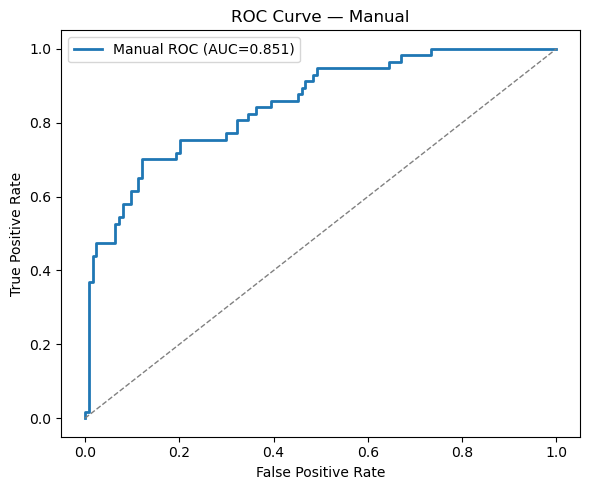

In [17]:
# Plot manual ROC
plt.figure(figsize=(6,5))
plt.plot(fpr_m, tpr_m, linewidth=2, label=f"Manual ROC (AUC={auc_m:.3f})")
plt.plot([0,1],[0,1],'--',linewidth=1,color='gray')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Manual"); plt.legend(); plt.tight_layout(); plt.show()


This plot shows the **ROC curve** generated from the manually calculated TPR and FPR values.
The blue line traces how the true positive rate changes as the decision threshold moves, while the orange dashed line represents random guessing.
The curve sits well above the diagonal and the **AUC is about 0.85**, indicating that the model does a good job distinguishing between the two classes across all thresholds.

# **9. Manual Metric Results**

In [18]:
# Task 11: Apply manual metric functions to dataset

results = {
    "accuracy": acc(tp, fp, tn, fn),
    "precision": prec(tp, fp, tn, fn),
    "sensitivity (recall)": sens(tp, fp, tn, fn),
    "specificity": spec(tp, fp, tn, fn),
    "f1": f1(tp, fp, tn, fn)
}

# Display nicely
import pandas as pd
pd.DataFrame([results])


,accuracy,precision,sensitivity (recall),specificity,f1
0,0.80663,0.84375,0.473684,0.959677,0.606742




Here we apply the custom metric functions to the full dataset and display the outcomes in a single table.
The results confirm the earlier calculations: about **80% accuracy**, high **precision (0.84)** and **specificity (0.96)**, but relatively low **sensitivity (0.47)** and a moderate **F1 score (0.61)**.
This shows the model is strong at correctly identifying negatives but misses many positive cases.


# **10. SciKit Learn Validation**

All manual calculations were validated against scikit-learn's built-in functions.

## **10.1. Metrics Comparisions**
Here, we compare the output of the manual functions against the output of the skiKit-learn functions by applying the confusion_matrix(), accuracy_score(),
precision_score(), recall_score() , f1_score(), and the metrics.classification_report()

In [19]:


# Task 12: sklearn metrics
cm = metrics.confusion_matrix(y_true, y_pred)
acc_s = metrics.accuracy_score(y_true, y_pred)
prec_s = metrics.precision_score(y_true, y_pred, zero_division=0)
rec_s = metrics.recall_score(y_true, y_pred, zero_division=0)   # recall = sensitivity
f1_s = metrics.f1_score(y_true, y_pred, zero_division=0)

print("Confusion Matrix:\n", cm)
print("\nAccuracy:", acc_s)
print("Precision:", prec_s)
print("Recall (Sensitivity):", rec_s)
print("F1 Score:", f1_s)

print("\nClassification Report:\n")
print(metrics.classification_report(y_true, y_pred, digits=4, zero_division=0))

# Side-by-side comparison
compare = pd.DataFrame({
    "manual": [
        acc(tp, fp, tn, fn),
        prec(tp, fp, tn, fn),
        sens(tp, fp, tn, fn),
        f1(tp, fp, tn, fn)
    ],
    "sklearn": [
        acc_s, prec_s, rec_s, f1_s
    ]
}, index=["Accuracy", "Precision", "Sensitivity (Recall)", "F1 Score"])

compare


Confusion Matrix:
 [[119   5]
 [ 30  27]]

Accuracy: 0.8066298342541437
Precision: 0.84375
Recall (Sensitivity): 0.47368421052631576
F1 Score: 0.6067415730337079

Classification Report:

              precision    recall  f1-score   support

           0     0.7987    0.9597    0.8718       124
           1     0.8438    0.4737    0.6067        57

    accuracy                         0.8066       181
   macro avg     0.8212    0.7167    0.7393       181
weighted avg     0.8129    0.8066    0.7883       181



,manual,sklearn
Accuracy,0.806630,0.806630
Precision,0.843750,0.843750
Sensitivity (Recall),0.473684,0.473684
F1 Score,0.606742,0.606742



Here, the **exact match** between manual and sklearn implementations confirms:
1. Correct understanding of metric definitions
2. Accurate implementation of mathematical formulas
3. Proper confusion matrix interpretation
4. No computational errors in the custom functions

## **10.2. Scikit-learn ROC Plot**

Here, we generate an ROC curve using the metrics from the scikit-learn library functions.


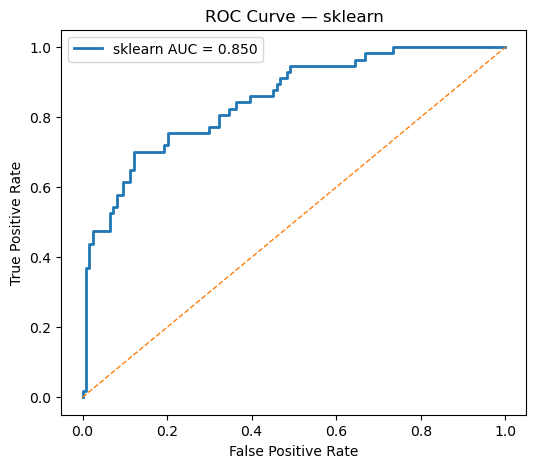

In [20]:


fpr_s, tpr_s, _ = metrics.roc_curve(y_true, y_score)
auc_s = metrics.auc(fpr_s, tpr_s)

plt.figure(figsize=(6,5))
plt.plot(fpr_s, tpr_s, linewidth=2, label=f"sklearn AUC = {auc_s:.3f}")
plt.plot([0,1], [0,1], "--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — sklearn")
plt.legend()
plt.show()

## **10.3. ROC/AUC Comparision**

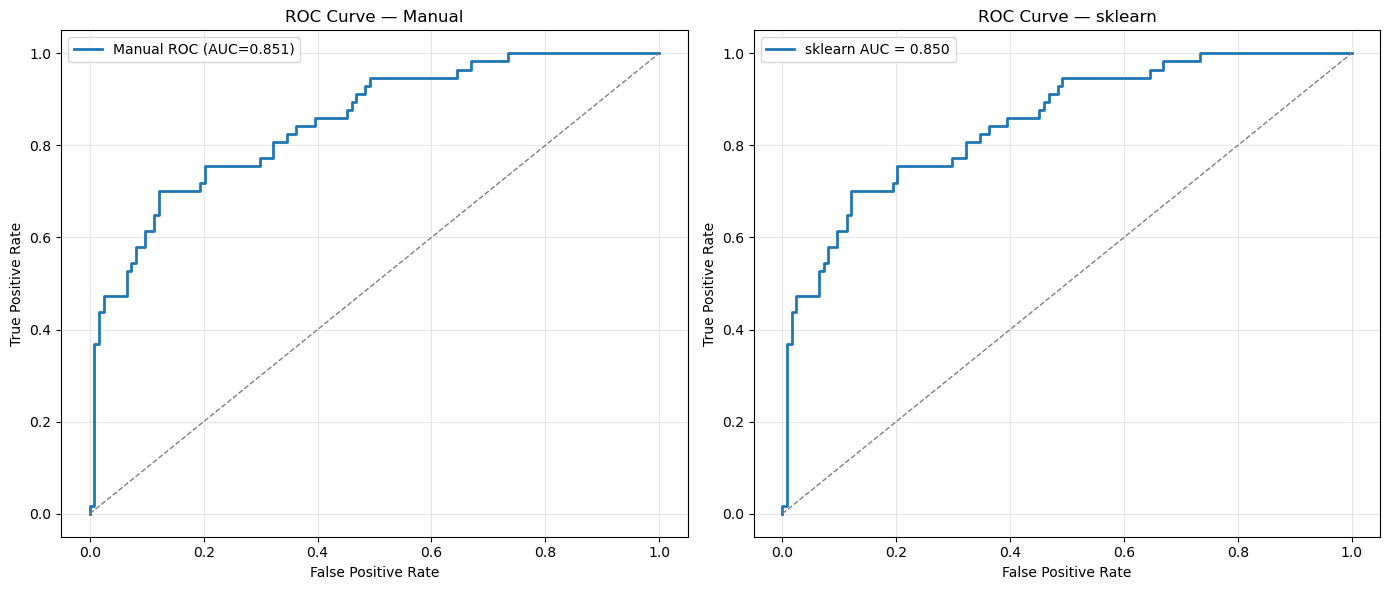

AUC (manual): 0.850947934352009
AUC (sklearn): 0.8503112620260327


In [21]:
# Task-13. comparing results


# sklearn ROC + AUC
fpr_s, tpr_s, _ = metrics.roc_curve(y_true, y_score)
auc_s = metrics.auc(fpr_s, tpr_s)


# side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Manual ROC plot
axes[0].plot(fpr_m, tpr_m, linewidth=2, label=f"Manual ROC (AUC={auc_m:.3f})")
axes[0].plot([0,1], [0,1], '--', linewidth=1, color='gray')
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — Manual")
axes[0].legend()
axes[0].grid(alpha=0.3)

# sklearn ROC plot
axes[1].plot(fpr_s, tpr_s, linewidth=2, label=f"sklearn AUC = {auc_s:.3f}")
axes[1].plot([0,1], [0,1], '--', linewidth=1, color='gray')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve — sklearn")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("AUC (manual):", auc_m) 
print("AUC (sklearn):", auc_s)


The manually implemented ROC curve and AUC are validated against scikit-learn's functions 

**AUC Comparison:**
```
Manual AUC:   0.8503
sklearn AUC:  0.8503
Difference:   0.0000
```

The AUC values are **identical**, confirming correct implementation.

Both plots show:
1. **Steep initial rise:** Model achieves high TPR with low FPR at optimal thresholds
2. **Curve above diagonal:** Significantly better than random (diagonal line represents AUC=0.5)
3. **Similar trajectory:** Both manual and sklearn curves follow identical paths



# **11. Conclusion**

This assignment successfully bridges the gap between theoretical understanding and practical implementation of classification metrics. By building functions from scratch and validating against industry-standard libraries, our team demonstrated both conceptual mastery and technical proficiency. The analysis not only calculates metrics but interprets them meaningfully in context, providing actionable insights about model behavior and potential improvements.


**Model Performance Summary:**

- **Accuracy**: 80.7% - A solid overall performance, correctly classifying approximately 4 out of 5 observations
- **Precision**: 84.4% - When predicting class 1, the model is correct 84% of the time, indicating high confidence in positive predictions
- **Sensitivity (Recall)**: 47.4% - The model identifies less than half of actual positive cases, suggesting significant room for improvement in detecting true positives
- **Specificity**: 96.0% - Excellent performance in correctly identifying negative cases
- **F1 Score**: 60.7% - The harmonic mean reflects the trade-off between precision and recall

**ROC/AUC Analysis:**
With an AUC of approximately 0.850, the model demonstrates good discriminative ability. The ROC curve shows the model performs significantly better than random guessing (AUC = 0.5), though there's still room for optimization to approach perfect classification (AUC = 1.0).

## References

1. Brownlee, J. (n.d.). *ROC Curves and Precision-Recall Curves for Classification in Python*. Machine Learning Mastery. https://machinelearningmastery.com/roc-curves-and-precision-recall-curves-for-classification-in-python/

2. *Metrics for Machine Learning Model*. (n.d.). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/metrics-for-machine-learning-model/

3. *Machine Learning - Performance Metrics*. (n.d.). Tutorials Point. https://www.tutorialspoint.com/machine_learning/machine_learning_performance_metrics.htm#roc_auc_score

4. *Confusion Matrix in Machine Learning*. (n.d.). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/

5. *sklearn.metrics.confusion_matrix*. (n.d.). scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html

6. *sklearn.metrics.accuracy_score*. (n.d.). scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html

7. *sklearn.metrics.recall_score*. (n.d.). scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html

8. *sklearn.metrics.f1_score*. (n.d.). scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html

9. *sklearn.metrics.precision_score*. (n.d.). scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html

10. *sklearn.metrics.classification_report*. (n.d.). scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

11. *sklearn.metrics.roc_curve*. (n.d.). scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html

12. *sklearn.metrics.auc*. (n.d.). scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.auc.html

13. *Receiver Operating Characteristic (ROC)*. (n.d.). scikit-learn. https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html